# CVLAB Summer Project — Stage 1: Classification Baselines

**DTD · FGVC-Aircraft · Oxford Flowers-102 | frozen pretrained encoders**

The goal of Stage 1 is a reliable, reproducible classification pipeline built on **frozen** pretrained encoders. No flow-matching component appears at this stage: the selected prototype branch carries into Stage 2, and the linear-probe setting carries into Stage 3.

The specification (`_docs/stage_1.pdf`) lists three candidate baselines and asks each group to implement the linear probe plus **one** of the two prototype branches. We implement all three so the branch that continues into Stage 2 can be chosen from measured results:

1. **Linear probe** (required) — a multiclass linear classifier $s = Wz + b$ on frozen features, softmax cross-entropy, only $W$ and $b$ trained.
2. **Image-derived class prototypes** (branch A) — $\mu_c = \mathrm{normalize}\left(\frac{1}{|S_c|}\sum_{i \in S_c} \mathrm{normalize}(z_i)\right)$, classify by $\hat{y} = \arg\max_c \cos(z, \mu_c)$.
3. **Zero-shot CLIP** (branch B) — text-derived class prototypes from CLIP RN50 prompts, $\hat{y} = \arg\max_c \cos(z, t_c)$; uses no labeled training images.

**Protocol.** All classes, official train / validation / test splits, never merging train and validation. Training-set sizes $K \in \{5, 10, \text{full}\}$ images per class; the 5- and 10-shot settings use balanced subsets of the official training split with seeds $\{0,1,2\}$. The validation split is used for model selection (linear-probe checkpointing) and the **complete official test split** only for the final top-1 accuracy.

**Group choices** (documented in `docs/adr/0005-group-choices-within-the-spec.md`): the spec's required pair is DTD + FGVC-Aircraft; Flowers-102 is run additionally and marked ‡ throughout. DINOv2 ViT-S/14 is used on FGVC-Aircraft, the fine-grained task. ResNet-18 is used on all datasets. CLIP RN50 is used for the zero-shot branch only, as the spec restricts it.

## 1 · Environment and configuration

In [1]:
import sys
from pathlib import Path

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO))

import json

import pandas as pd
from IPython.display import Image, display

from src.utils import load_config

pd.set_option("display.precision", 2)
pd.set_option("display.max_rows", 200)

with open(REPO / "results" / "runtime_summary.json") as f:
    runtime = json.load(f)
print("Runtime:", json.dumps(runtime, indent=2))

cfg = load_config()
print("\nTraining-set sizes K:", cfg["shots"])
print("Subset seeds (5/10-shot):", cfg["subset_seeds"],
      "| initialization seeds (full):", cfg["init_seeds"])
print("Linear probe:", json.dumps(cfg["linear_probe"], indent=2))

Runtime: {
  "python": "3.12.3",
  "platform": "Windows-10-10.0.19045-SP0",
  "torch": "2.9.1+rocm7.2.1",
  "cuda_available": true,
  "device_name": "AMD Radeon RX 7900 XTX",
  "device": "cuda",
  "matmul_ok": true
}

Training-set sizes K: [5, 10, 'full']
Subset seeds (5/10-shot): [0, 1, 2] | initialization seeds (full): [0, 1, 2]
Linear probe: {
  "optimizer": "adamw",
  "lr": 0.001,
  "weight_decay": 0.0001,
  "batch_size": 64,
  "max_epochs": 200,
  "checkpoint_selection": "highest_validation_accuracy"
}


All experiments ran on the machine above. Every encoder is **frozen** and used with the preprocessing associated with its own checkpoint:

| Encoder | Source | Representation | Used on |
|---|---|---|---|
| ResNet-18 (ImageNet-1K) | torchvision `ResNet18_Weights.IMAGENET1K_V1` | 512-d, before the final classification layer | all datasets |
| DINOv2 ViT-S/14 | `facebook/dinov2-small` | final class token (384-d) | FGVC-Aircraft |
| CLIP RN50 | official OpenAI `clip` | image encoder (1024-d) + text encoder | zero-shot branch only |

Train, validation and test features are extracted **once** per (dataset, encoder) and cached; all classifier training and evaluation runs on those caches.

## 2 · Datasets, official splits and training subsets

All classes are used, with the **official** splits: DTD uses partition 1, FGVC-Aircraft uses the `variant` annotation level, Flowers-102 uses its published split. Training and validation splits are never merged.

In [2]:
splits = pd.read_csv(REPO / "results" / "metrics" / "dataset_splits.csv")
display(splits)

,Dataset,dataset,split,images,classes,per_class_min,per_class_median,per_class_max,spec_selected
0,DTD,dtd,train,1880,47,40,40,40,True
1,DTD,dtd,val,1880,47,40,40,40,True
2,DTD,dtd,test,1880,47,40,40,40,True
3,FGVC-Aircraft,fgvc_aircraft,train,3334,100,33,33,34,True
4,FGVC-Aircraft,fgvc_aircraft,val,3333,100,33,33,34,True
5,FGVC-Aircraft,fgvc_aircraft,test,3333,100,33,33,34,True
6,Oxford Flowers-102 ‡,flowers102,train,1020,102,10,10,10,False
7,Oxford Flowers-102 ‡,flowers102,val,1020,102,10,10,10,False
8,Oxford Flowers-102 ‡,flowers102,test,6149,102,20,46,238,False


For the 5-shot and 10-shot settings a **balanced** subset of the official training split is sampled with seeds {0, 1, 2}; the chosen indices are saved under `results/artifacts/subsets/` so that every encoder and every classification head is trained on bit-identical images. The `full` setting is the complete official training split.

Note the structural quirk visible in the table: Flowers-102's official training split contains exactly 10 images per class, so for that dataset the 10-shot setting *is* the full setting (its three 10-shot "runs" therefore see identical data and the spread is exactly zero). DTD (40 per class) and FGVC-Aircraft (~33 per class) give three genuinely distinct settings — which is why they are the spec-selected pair.

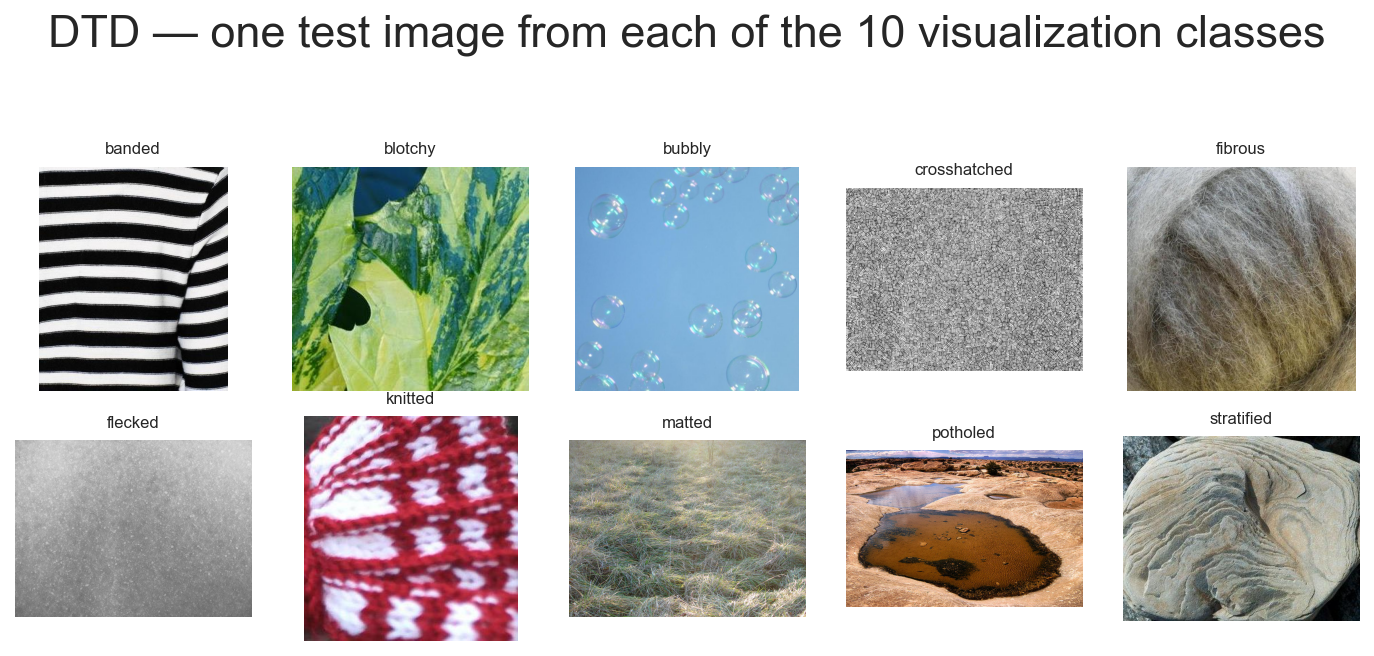

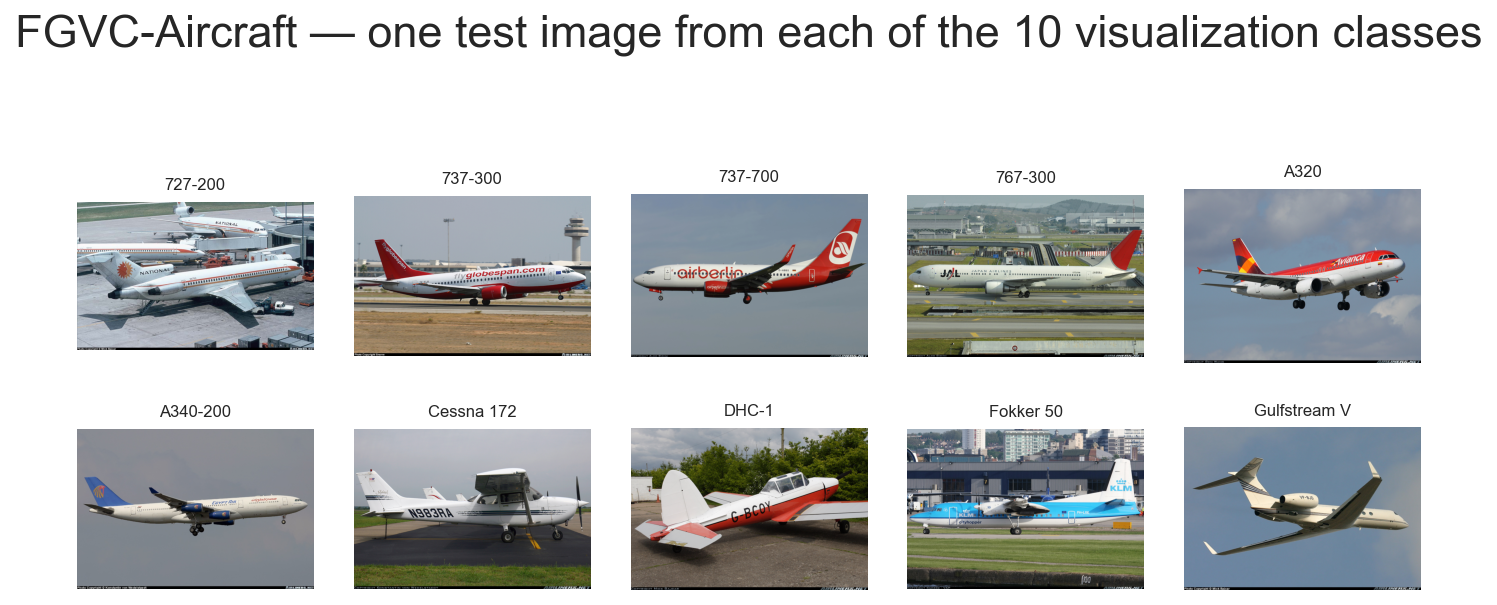

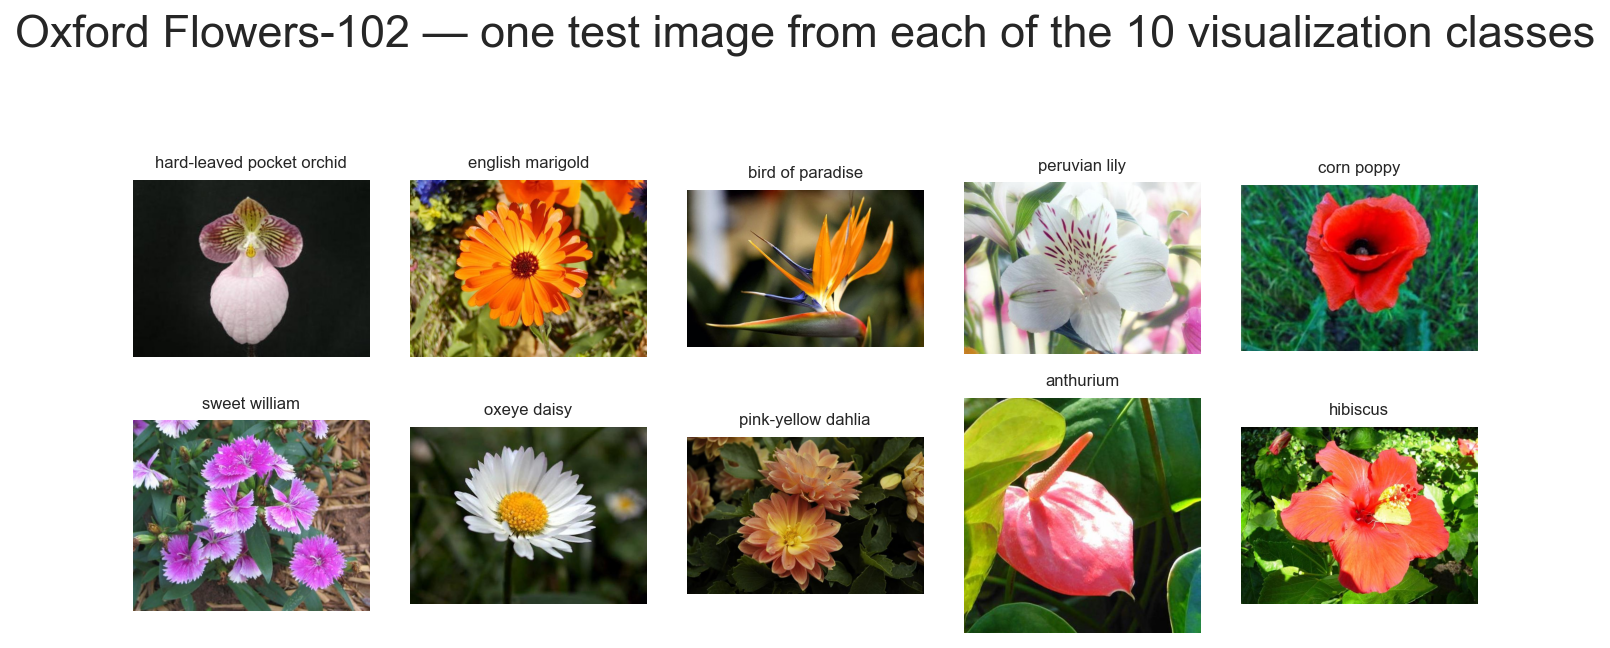

In [3]:
display(Image(str(REPO / "results" / "figures" / "samples_dtd.png"), width=760))
display(Image(str(REPO / "results" / "figures" / "samples_fgvc_aircraft.png"), width=760))
display(Image(str(REPO / "results" / "figures" / "samples_flowers102.png"), width=760))

## 3 · Methods

**Linear probe (required baseline).** A multiclass linear classifier $s = Wz + b$ over the frozen feature $z$; only $W$ and $b$ are trained, with softmax cross-entropy. The configuration is the one suggested by the specification, adopted unchanged and fixed a priori — AdamW, learning rate $10^{-3}$, weight decay $10^{-4}$, batch size 64, at most 200 epochs, and **checkpoint selection by highest validation accuracy**. No hyperparameter search was performed; the objective is a reasonable, stable probe, since the later comparison of interest concerns the FM layer.

**Image-derived class prototypes (branch A).** Features are $L_2$-normalized first, then

$$\mu_c = \mathrm{normalize}\left(\frac{1}{|S_c|}\sum_{i \in S_c} \mathrm{normalize}(z_i)\right), \qquad \hat{y} = \arg\max_c \cos(z, \mu_c),$$

where $S_c$ is the selected **training** subset for class $c$. There is nothing to train and no initialization, so the only source of run-to-run variation is which training images the subset seed selected.

**Zero-shot CLIP (branch B).** One text prototype per class from the frozen CLIP RN50 text encoder, using the dataset-specific prompt from the spec — `a photo of a {class} texture` (DTD), `a photo of a {class} aircraft` (FGVC-Aircraft), `a photo of a {class} flower` (Flowers-102). Image and text embeddings are normalized and classified with $\hat{y} = \arg\max_c \cos(z, t_c)$. This branch uses **no labeled training images**, so it produces exactly one result per dataset and is drawn as a horizontal reference line rather than a curve.

## 4 · Protocol integrity and provenance

Everything a reader needs to judge the numbers, in one place.

**Split discipline.** All classes, official train / validation / test splits, train and validation never merged. The validation split is used *only* for linear-probe checkpoint selection (highest validation accuracy). The complete official **test** split is used only for the final top-1 numbers reported below — no hyperparameter, encoder, subset or checkpoint was ever chosen by looking at test accuracy.

**Run and seed structure** (3 runs per training-set size, exactly as specified):

| Setting | What varies across the 3 runs | What is held fixed |
|---|---|---|
| 5-shot, 10-shot | balanced-subset seed ∈ {0, 1, 2} | classifier initialization (seed 0) |
| full — linear probe | classifier-initialization seed ∈ {0, 1, 2} | training set (the complete official split) |
| full — image prototypes | *nothing* — single deterministic run | — |
| zero-shot CLIP | *nothing* — single deterministic run, no training images | — |

Each setting therefore has a single interpretable source of variance: subset sampling at 5/10-shot, initialization at full. Single-run settings are reported without a standard deviation rather than as "± 0.00".

**Hyperparameter provenance.** The linear-probe configuration is the specification's suggested baseline, adopted unchanged and fixed before any result was observed: AdamW, lr 1e-3, weight decay 1e-4, batch size 64, ≤200 epochs, checkpoint on best validation accuracy. Feature extraction uses each checkpoint's own preprocessing. All values live in `config/config.json`; none was tuned.

**Reproducibility.** Balanced training subsets are saved as index files (`results/artifacts/subsets/`) carrying a fingerprint of the training-split labels, so every encoder and head trains on identical images and a dataset change fails loudly instead of silently shifting the data. Per-run accuracies are saved to `results/metrics/raw/`; `scripts/repro_check.py` re-derives every mean and standard deviation in the tables below from those raw arrays.

In [4]:
runs = pd.read_csv(REPO / "results" / "metrics" / "runs.csv")
print("individual runs recorded:", len(runs))
display(runs.groupby(["head", "k_shot"], sort=False)
            .agg(runs=("test_acc", "size"), seed_type=("seed_type", "first"))
            .reset_index())

individual runs recorded: 67


,head,k_shot,runs,seed_type
0,linear_probe,5shot,12,subset
1,image_prototype,5shot,12,subset
2,linear_probe,10shot,12,subset
3,image_prototype,10shot,12,subset
4,linear_probe,full,12,init
5,image_prototype,full,4,subset
6,zeroshot_clip,none,3,deterministic


## 5 · Results

### 5.1 Accuracy table

Top-1 accuracy (%) on the complete official test split, for every dataset, encoder, training-set size and implemented baseline. Generated programmatically from `results/metrics/summary.csv`. ‡ marks the dataset beyond the spec's required pair.

In [5]:
from IPython.display import Markdown

display(Markdown((REPO / "results" / "metrics" / "accuracy_table.md").read_text(encoding="utf-8")))

| Dataset | Encoder | Baseline | K = 5 | K = 10 | full train split | no training images |
|---|---|---|---|---|---|---|
| DTD | ResNet-18 | Linear probe | 45.60 ± 0.64 | 54.31 ± 0.28 | 62.84 ± 0.45 | — |
| DTD | ResNet-18 | Image prototypes | 46.51 ± 0.64 | 53.37 ± 1.04 | 58.78 | — |
| DTD | CLIP RN50 | Zero-shot CLIP | — | — | — | 39.79 |
| FGVC-Aircraft | ResNet-18 | Linear probe | 19.90 ± 1.72 | 27.36 ± 0.83 | 36.62 ± 0.27 | — |
| FGVC-Aircraft | ResNet-18 | Image prototypes | 16.04 ± 0.83 | 19.85 ± 0.47 | 25.20 | — |
| FGVC-Aircraft | DINOv2 | Linear probe | 36.47 ± 0.70 | 51.30 ± 0.95 | 67.21 ± 0.11 | — |
| FGVC-Aircraft | DINOv2 | Image prototypes | 23.11 ± 1.36 | 27.80 ± 1.17 | 34.41 | — |
| FGVC-Aircraft | CLIP RN50 | Zero-shot CLIP | — | — | — | 17.04 |
| Oxford Flowers-102 ‡ | ResNet-18 | Linear probe | 75.58 ± 0.84 | 83.22 ± 0.00 | 83.28 ± 0.11 | — |
| Oxford Flowers-102 ‡ | ResNet-18 | Image prototypes | 70.19 ± 0.14 | 75.22 ± 0.00 | 75.22 | — |
| Oxford Flowers-102 ‡ | CLIP RN50 | Zero-shot CLIP | — | — | — | 63.64 |

Top-1 accuracy (%) on the complete official test split. 5-shot / 10-shot: mean ± std over 3 training-subset seeds; full linear probe: mean ± std over 3 initialization seeds; full image prototypes and zero-shot CLIP are single deterministic runs. Zero-shot CLIP uses no labeled training images, so it has one value only. ‡ = beyond the spec's required pair of datasets. A standard deviation of exactly 0.00 at Flowers-102 K = 10 is not a rounding artifact: that dataset's official training split holds exactly 10 images per class, so all three 10-shot subsets are the same set of images.

### 5.2 Accuracy versus training-set size

Error bars are ± std over the 3 runs. Zero-shot CLIP uses no labeled training images, so it appears as a horizontal reference line rather than a curve.

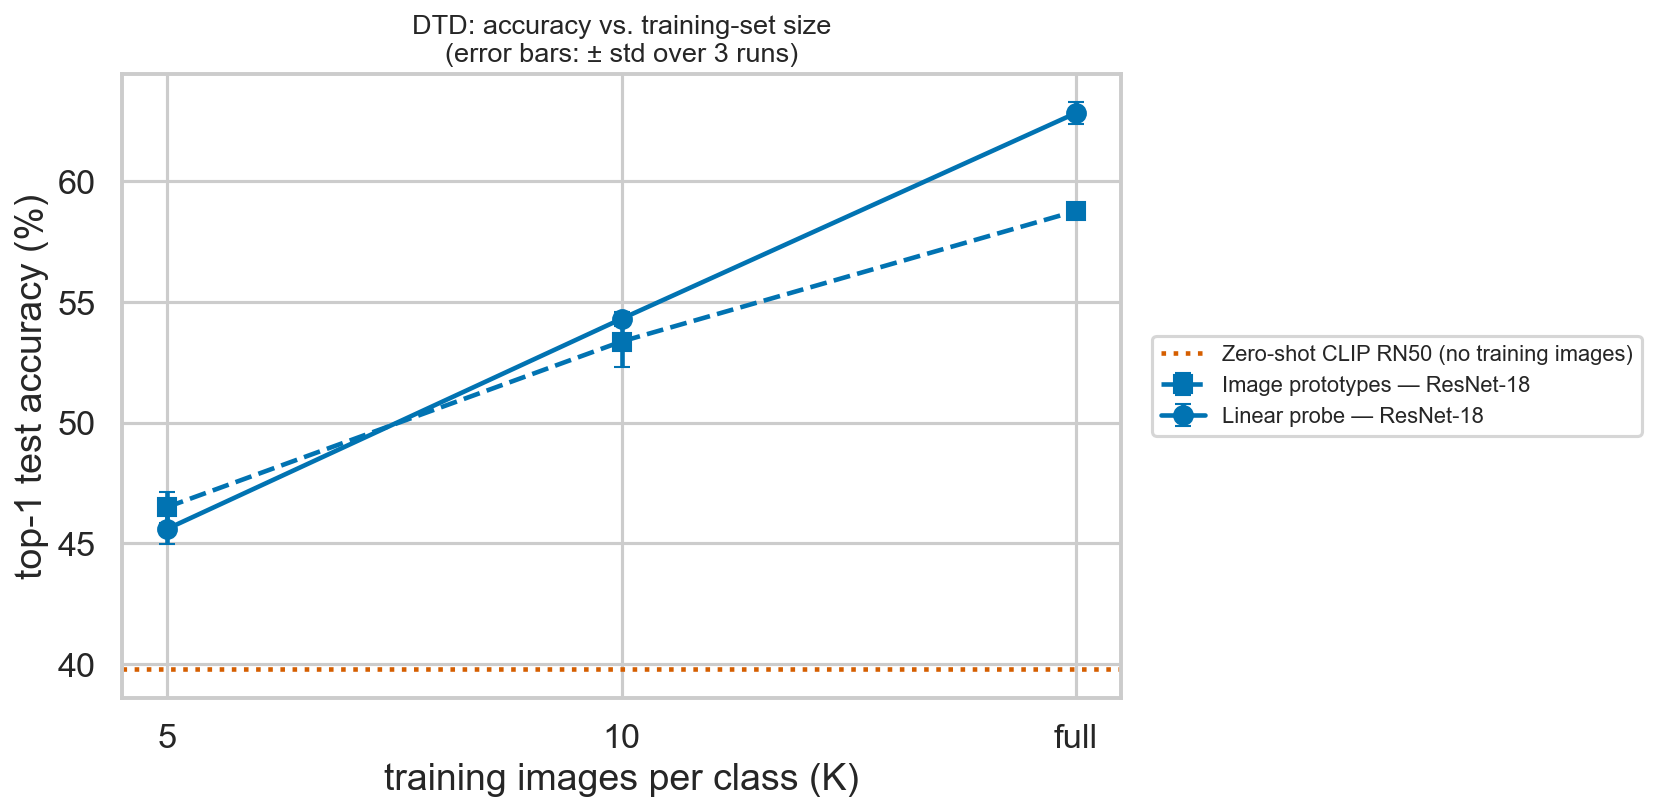

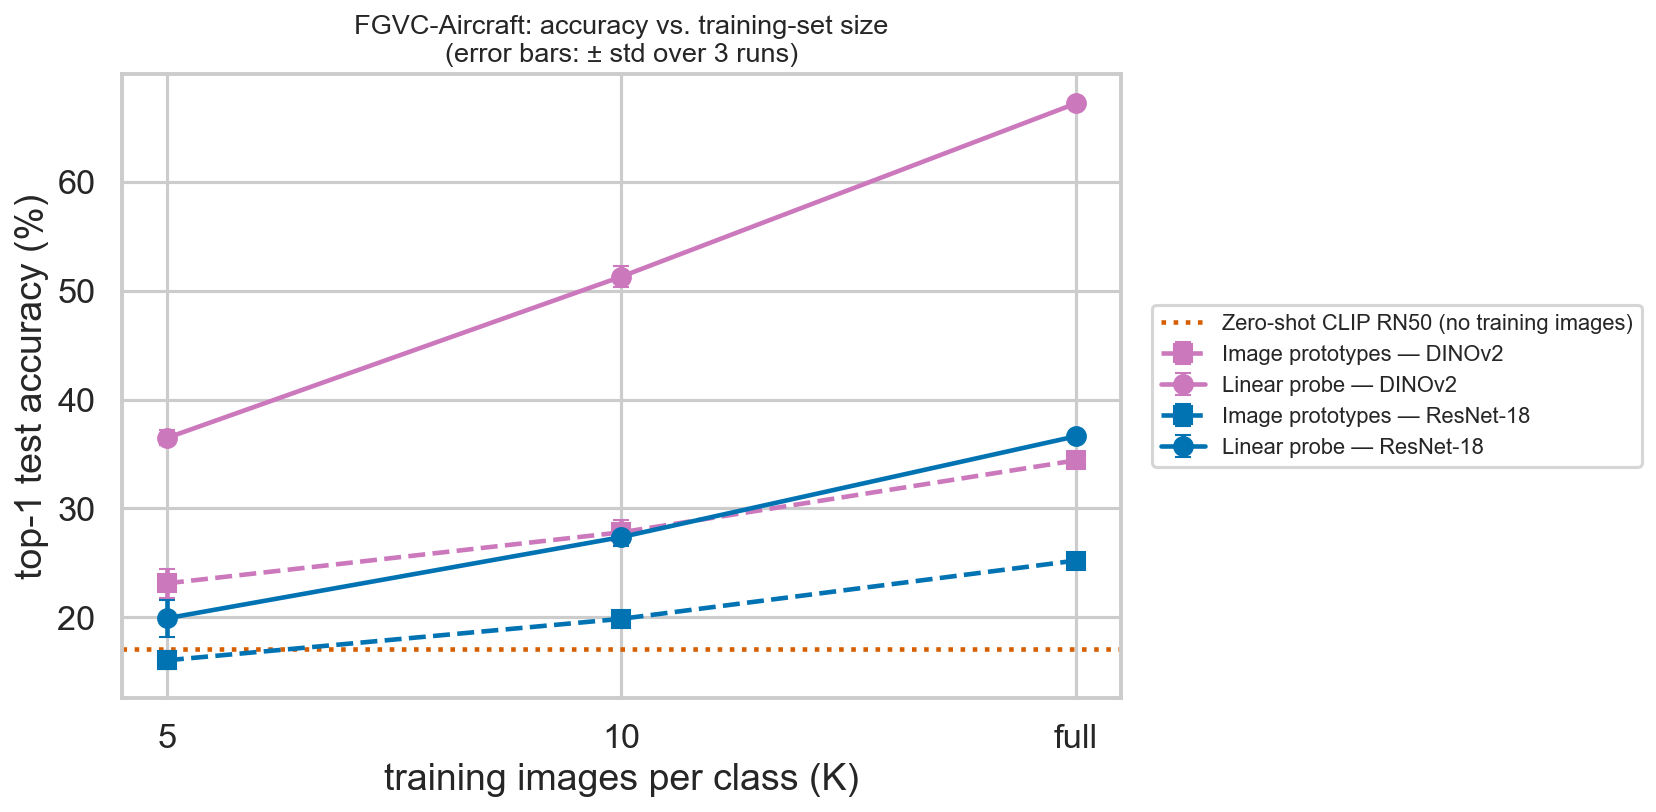

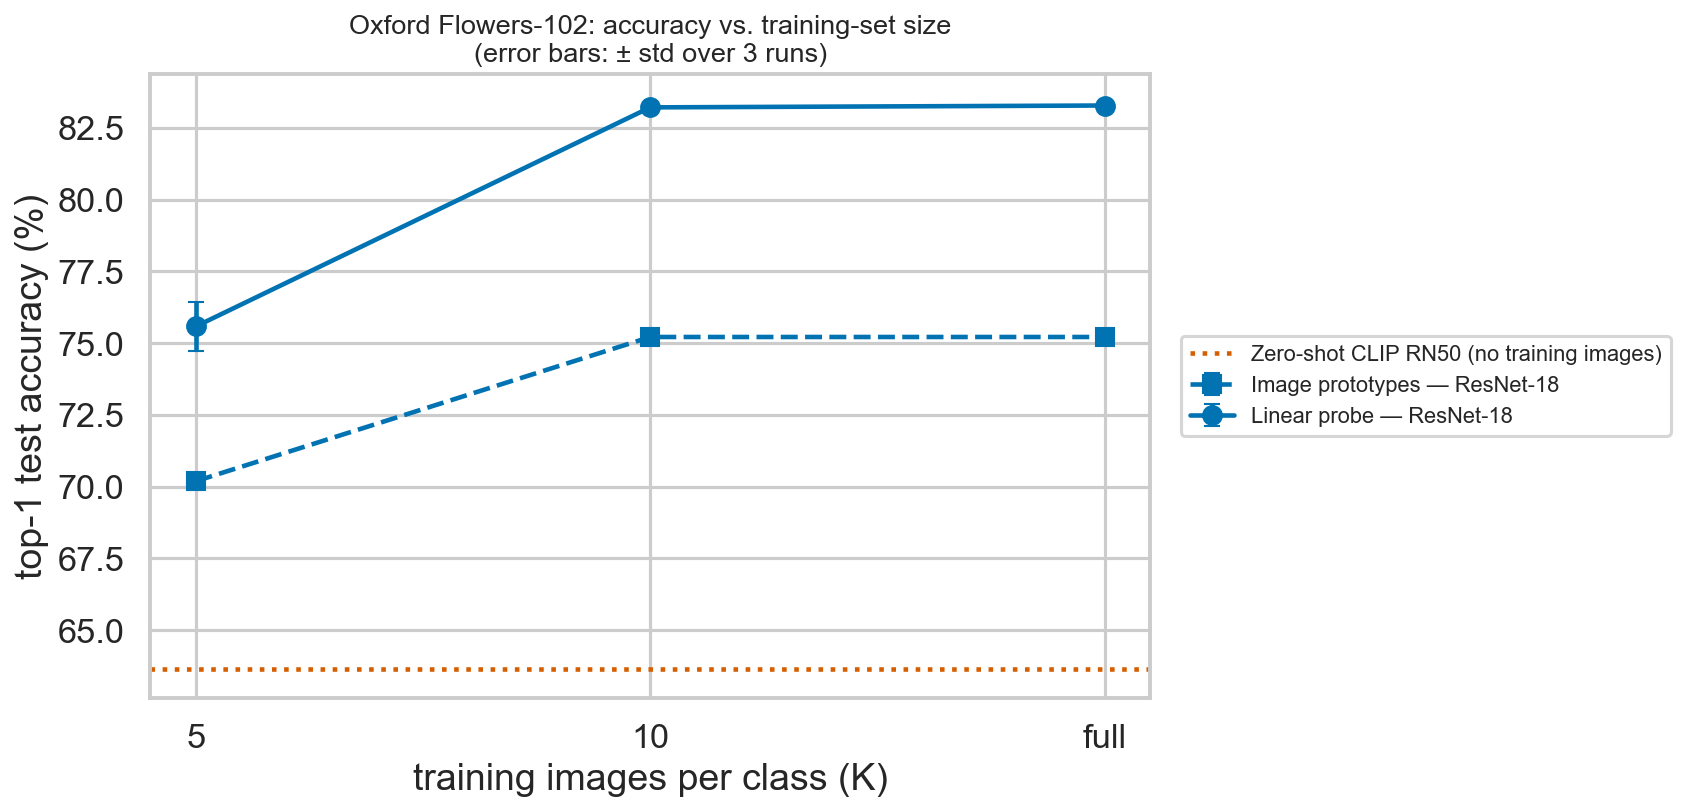

In [6]:
for ds in ("dtd", "fgvc_aircraft", "flowers102"):
    display(Image(str(REPO / "results" / "figures" / f"acc_vs_trainsize_{ds}.png"), width=820))

### 5.3 Linear-probe training curves

Representative 10-shot run (subset seed 0) for each dataset–encoder combination. The dashed line marks the epoch whose checkpoint was selected — the highest validation accuracy. These curves are the evidence that training is stable and show how much the validation loss diverges from the training loss, i.e. how much overfitting the probe incurs at this training-set size.

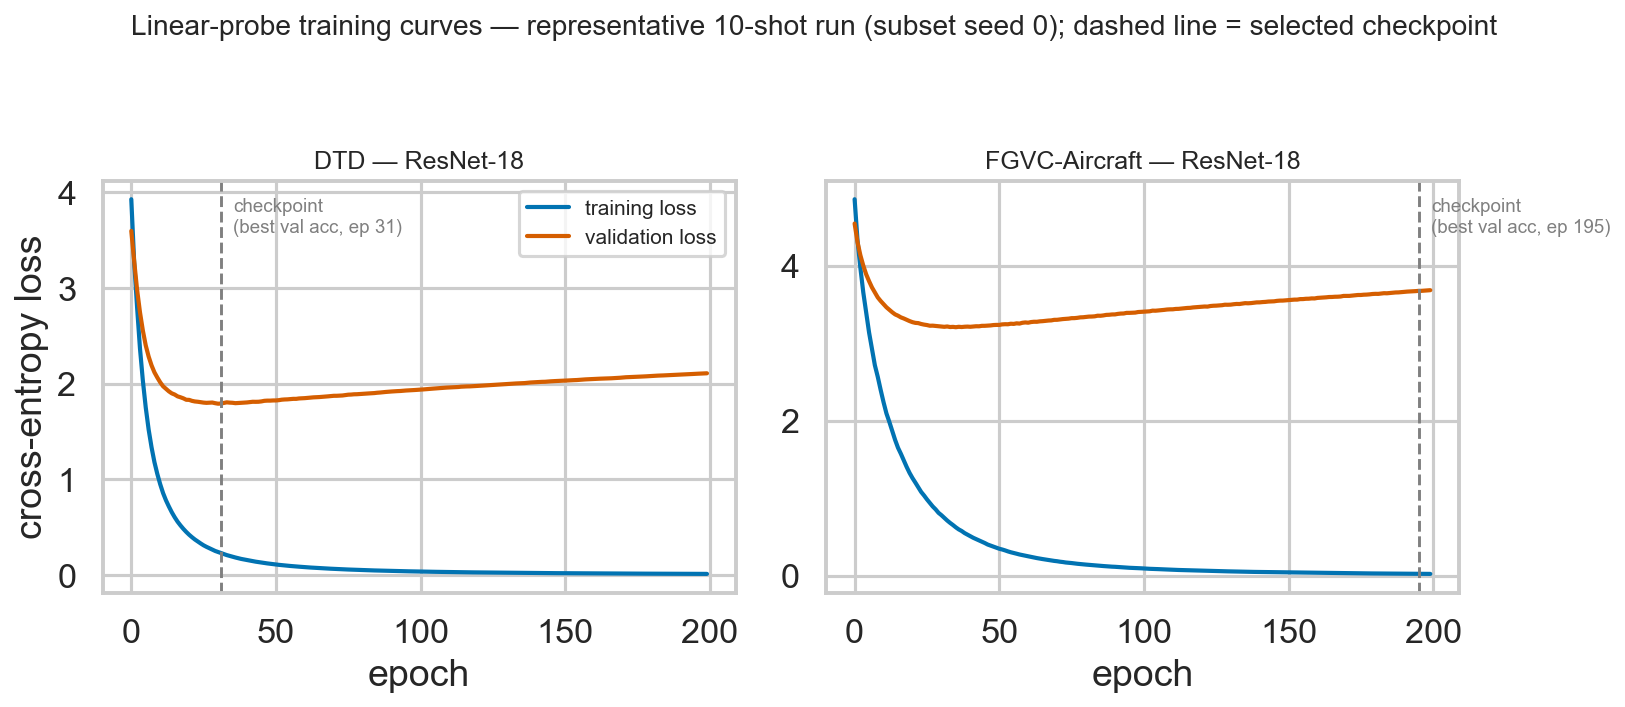

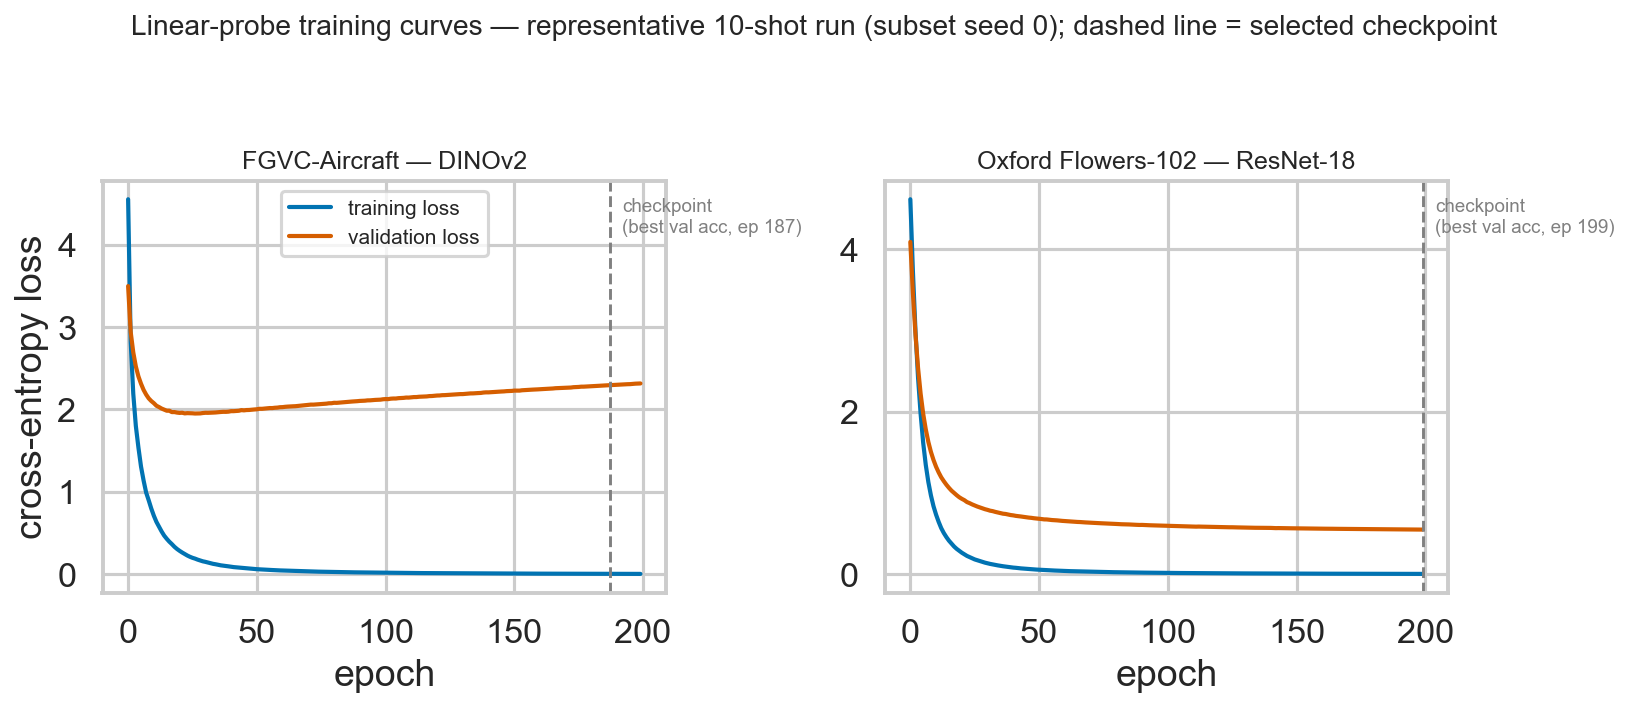

In [7]:
import glob

for p in sorted(glob.glob(str(REPO / "results" / "figures" / "training_curves_*.png"))):
    display(Image(p, width=900))

### 5.4 Confusion matrices

One **row-normalized** confusion matrix per dataset (rows sum to 1, so each row shows how the test images of one true class were distributed). The representative setting is the best full-training-split linear probe on that dataset — the configuration whose errors are most informative. The most frequent off-diagonal confusions are listed beside each matrix.

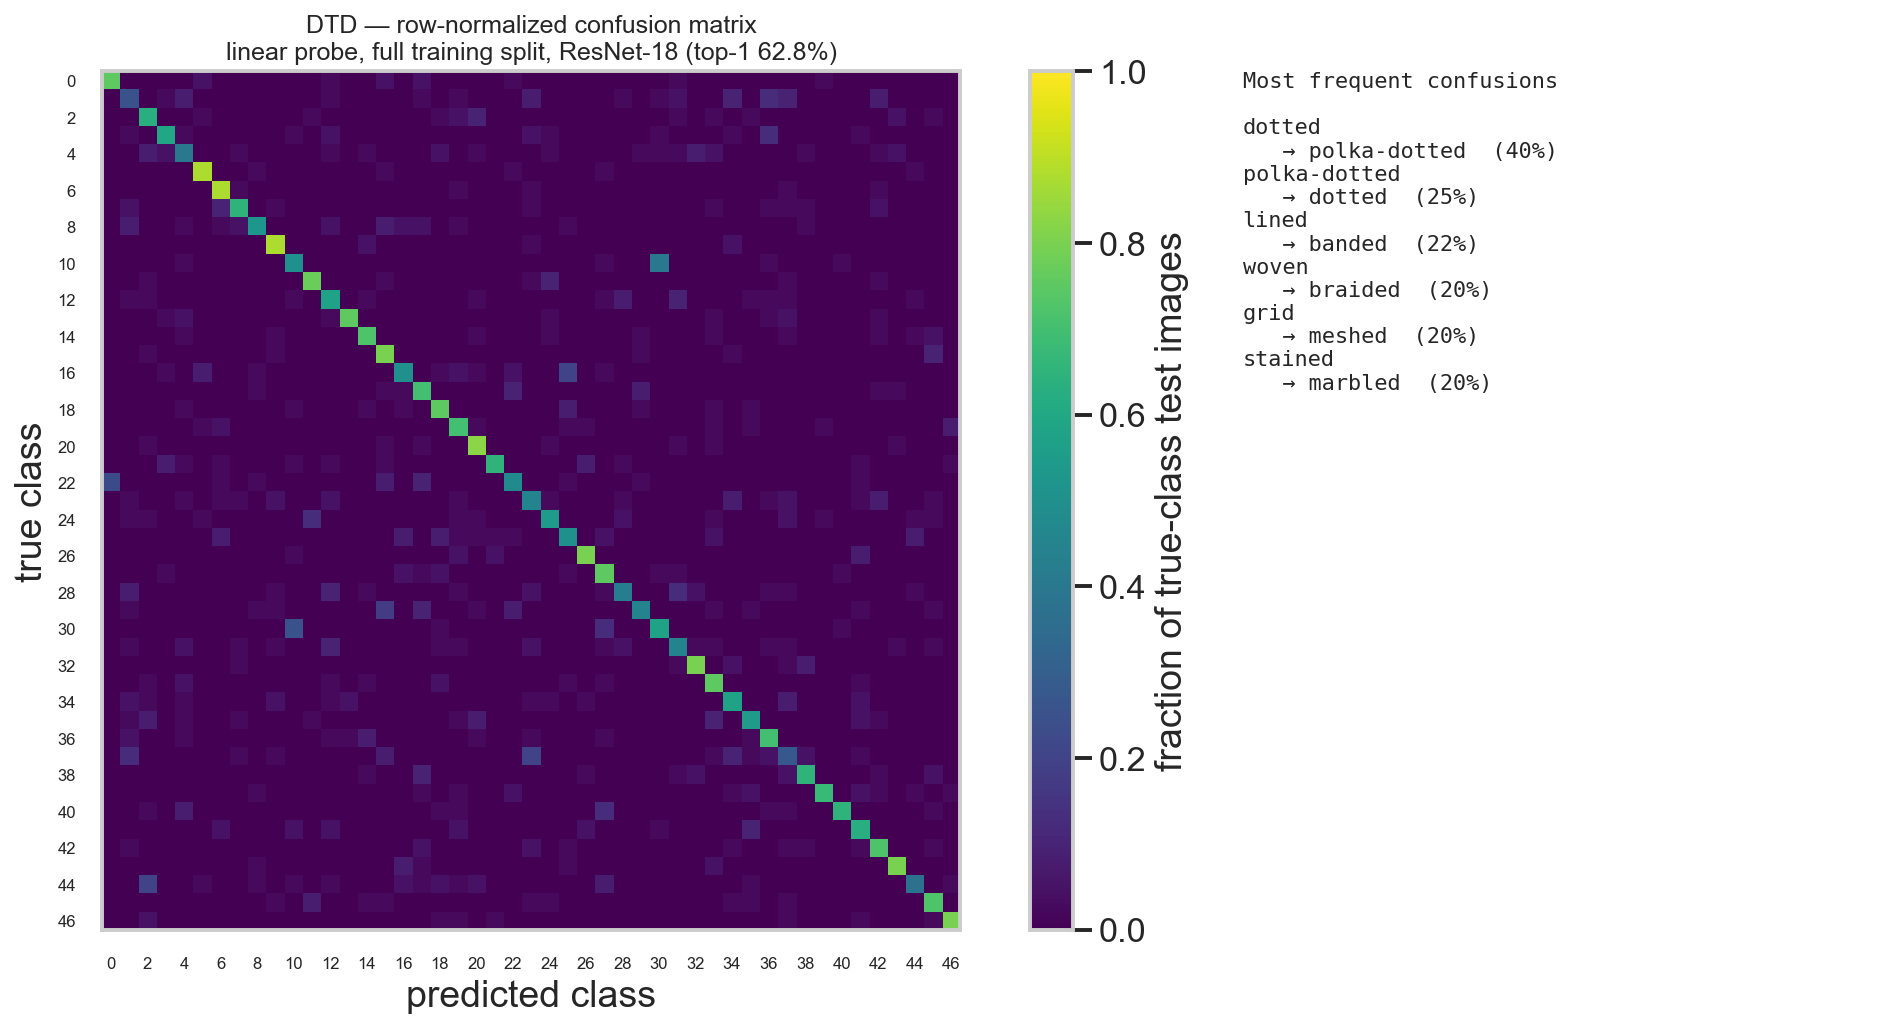

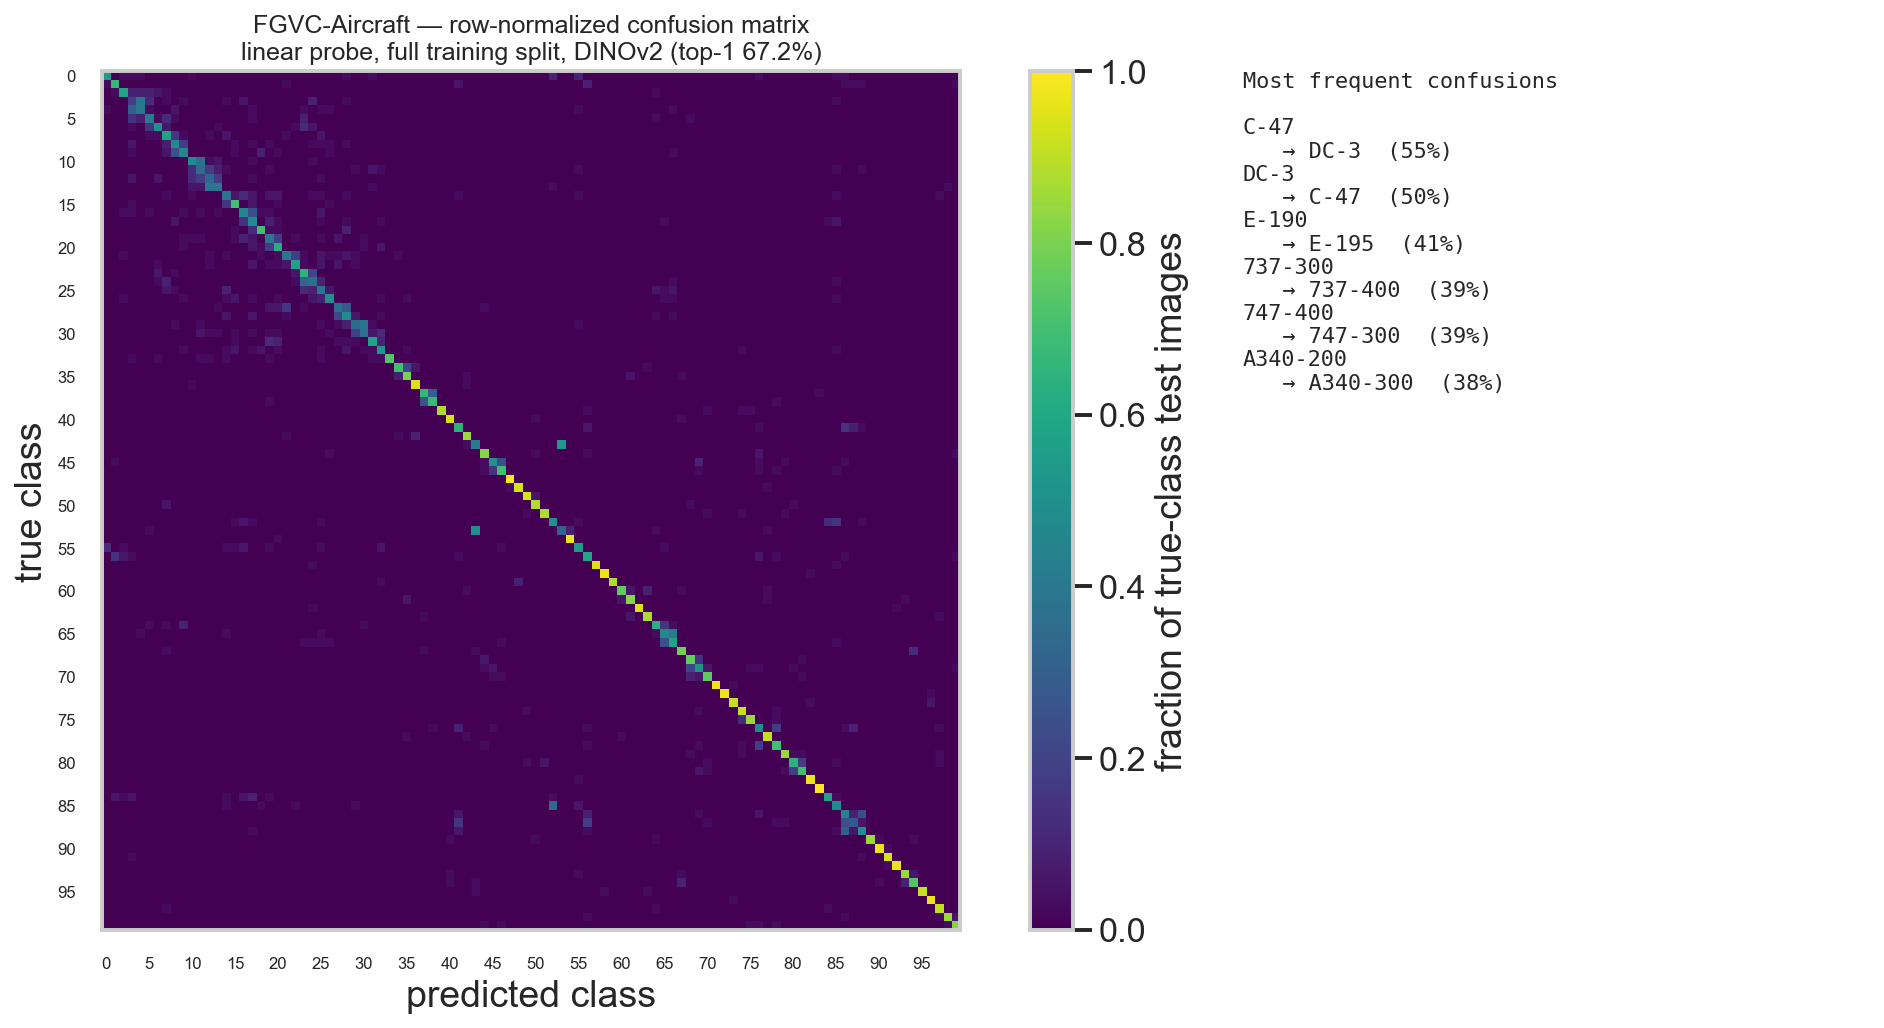

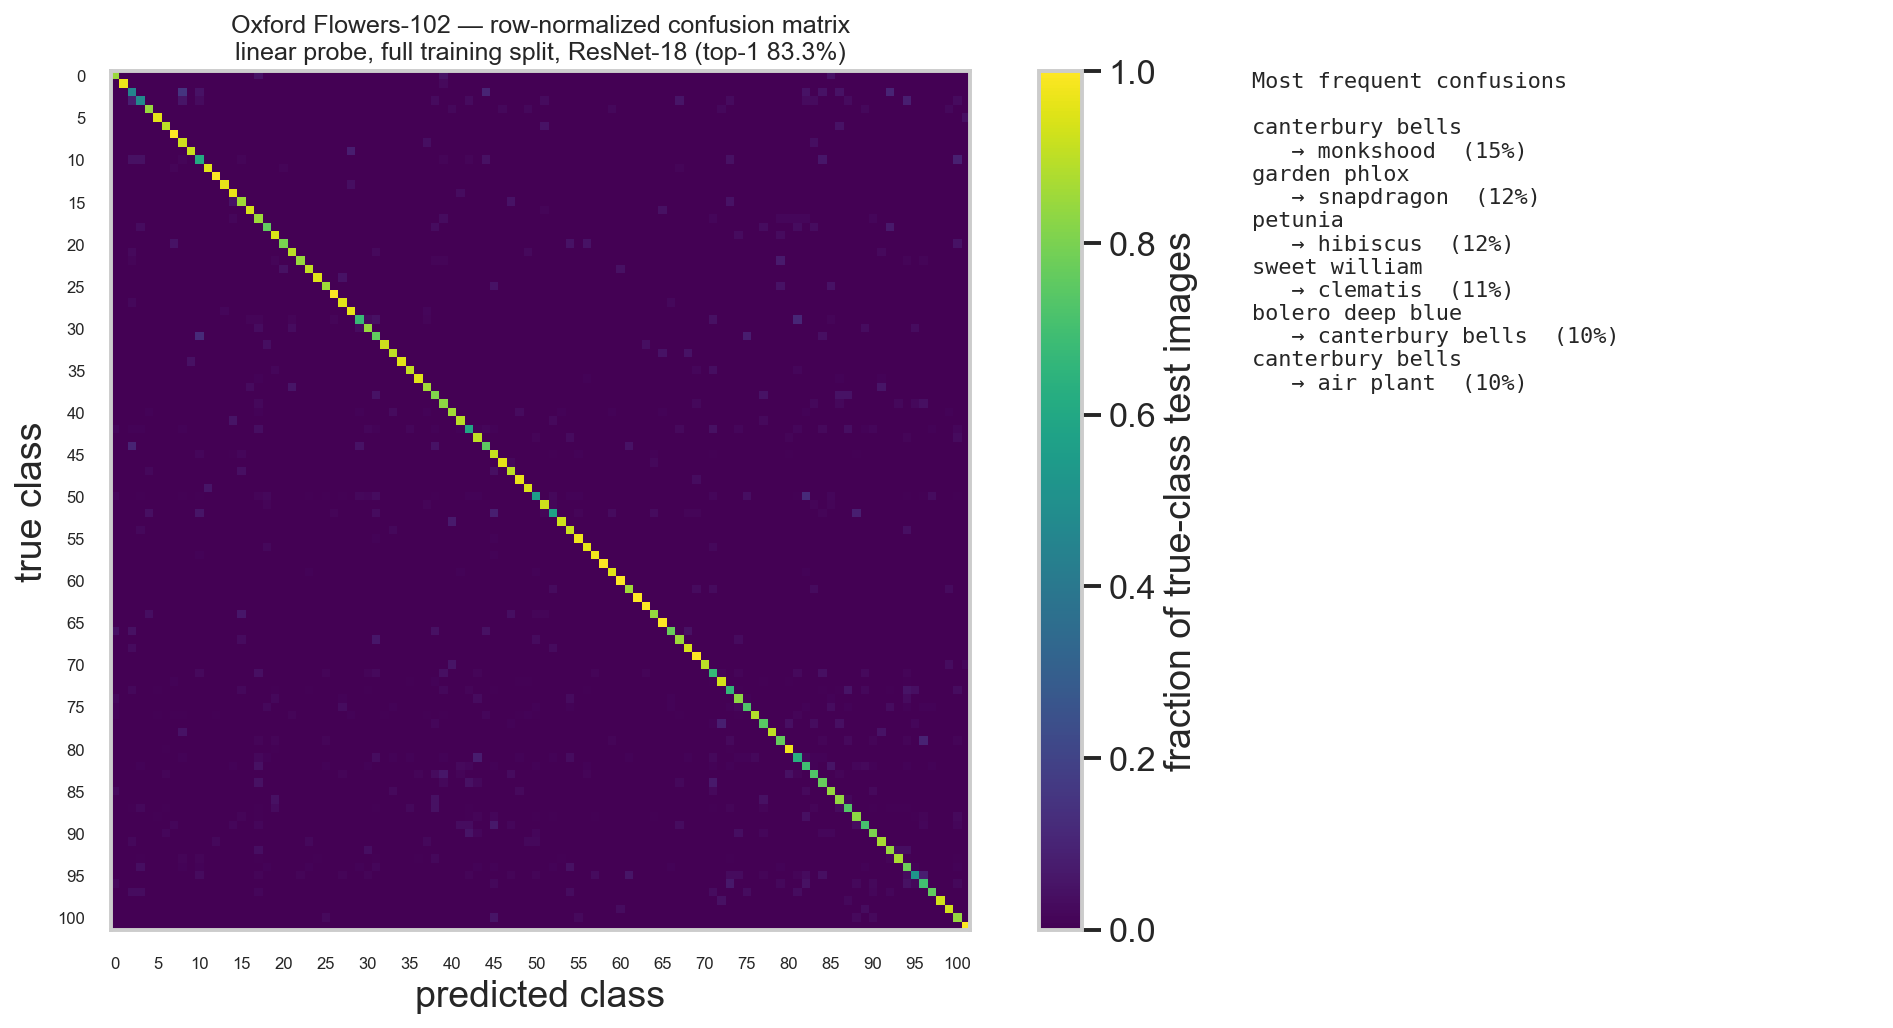

In [8]:
for ds in ("dtd", "fgvc_aircraft", "flowers102"):
    display(Image(str(REPO / "results" / "figures" / f"confusion_{ds}.png"), width=980))

### 5.5 Feature visualizations

Ten classes per dataset (chosen once with a fixed seed) with up to 40 test images each. For a given dataset the **same classes, the same test examples and the same class colours** are used in every panel, so encoders and methods can be compared directly.

Each figure shows both a PCA and a t-SNE view. Stars are the class prototypes: image-derived prototypes for ResNet-18 and DINOv2, text prototypes for CLIP RN50. Features are $L_2$-normalized before projection — the space in which the cosine classifier actually operates — and, as the spec requires, **the projection is fitted jointly to the image features and the prototypes shown in the plot**, so a prototype's position is directly comparable to the points around it.

These are qualitative views of the representation, not measurements of classification performance: both projections distort distances, t-SNE especially so.

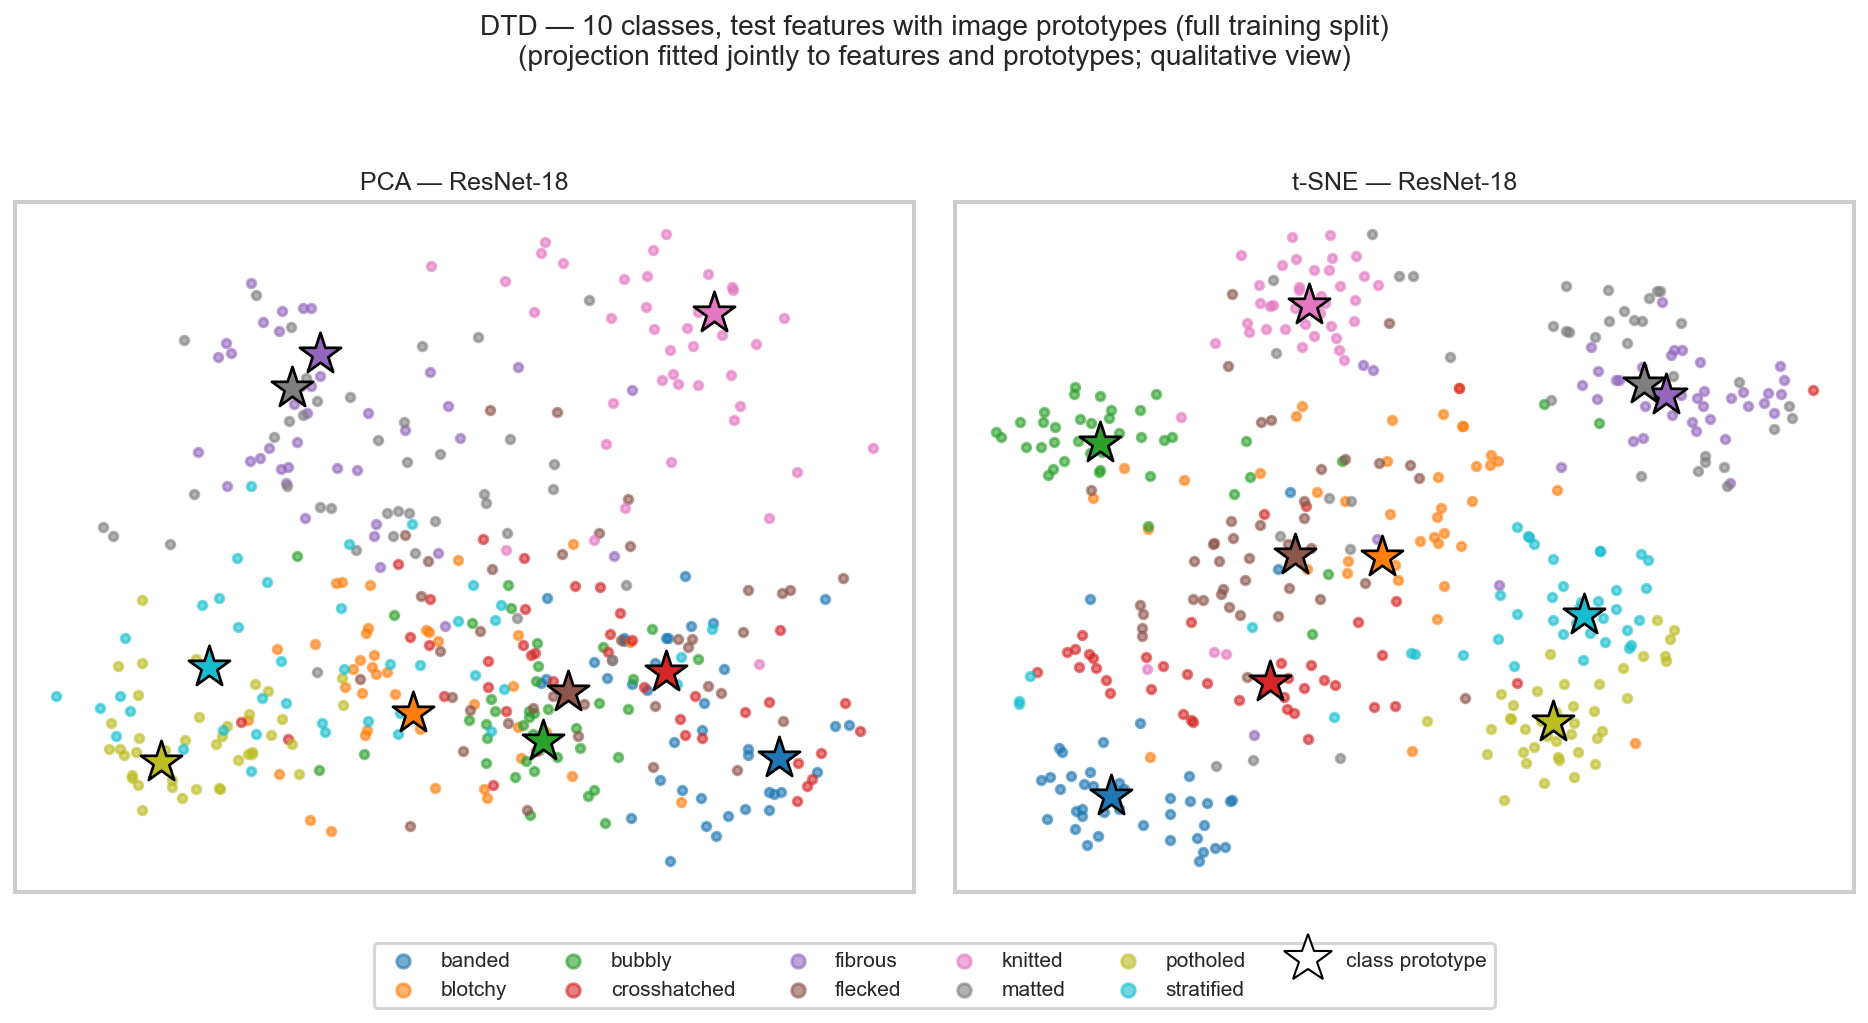

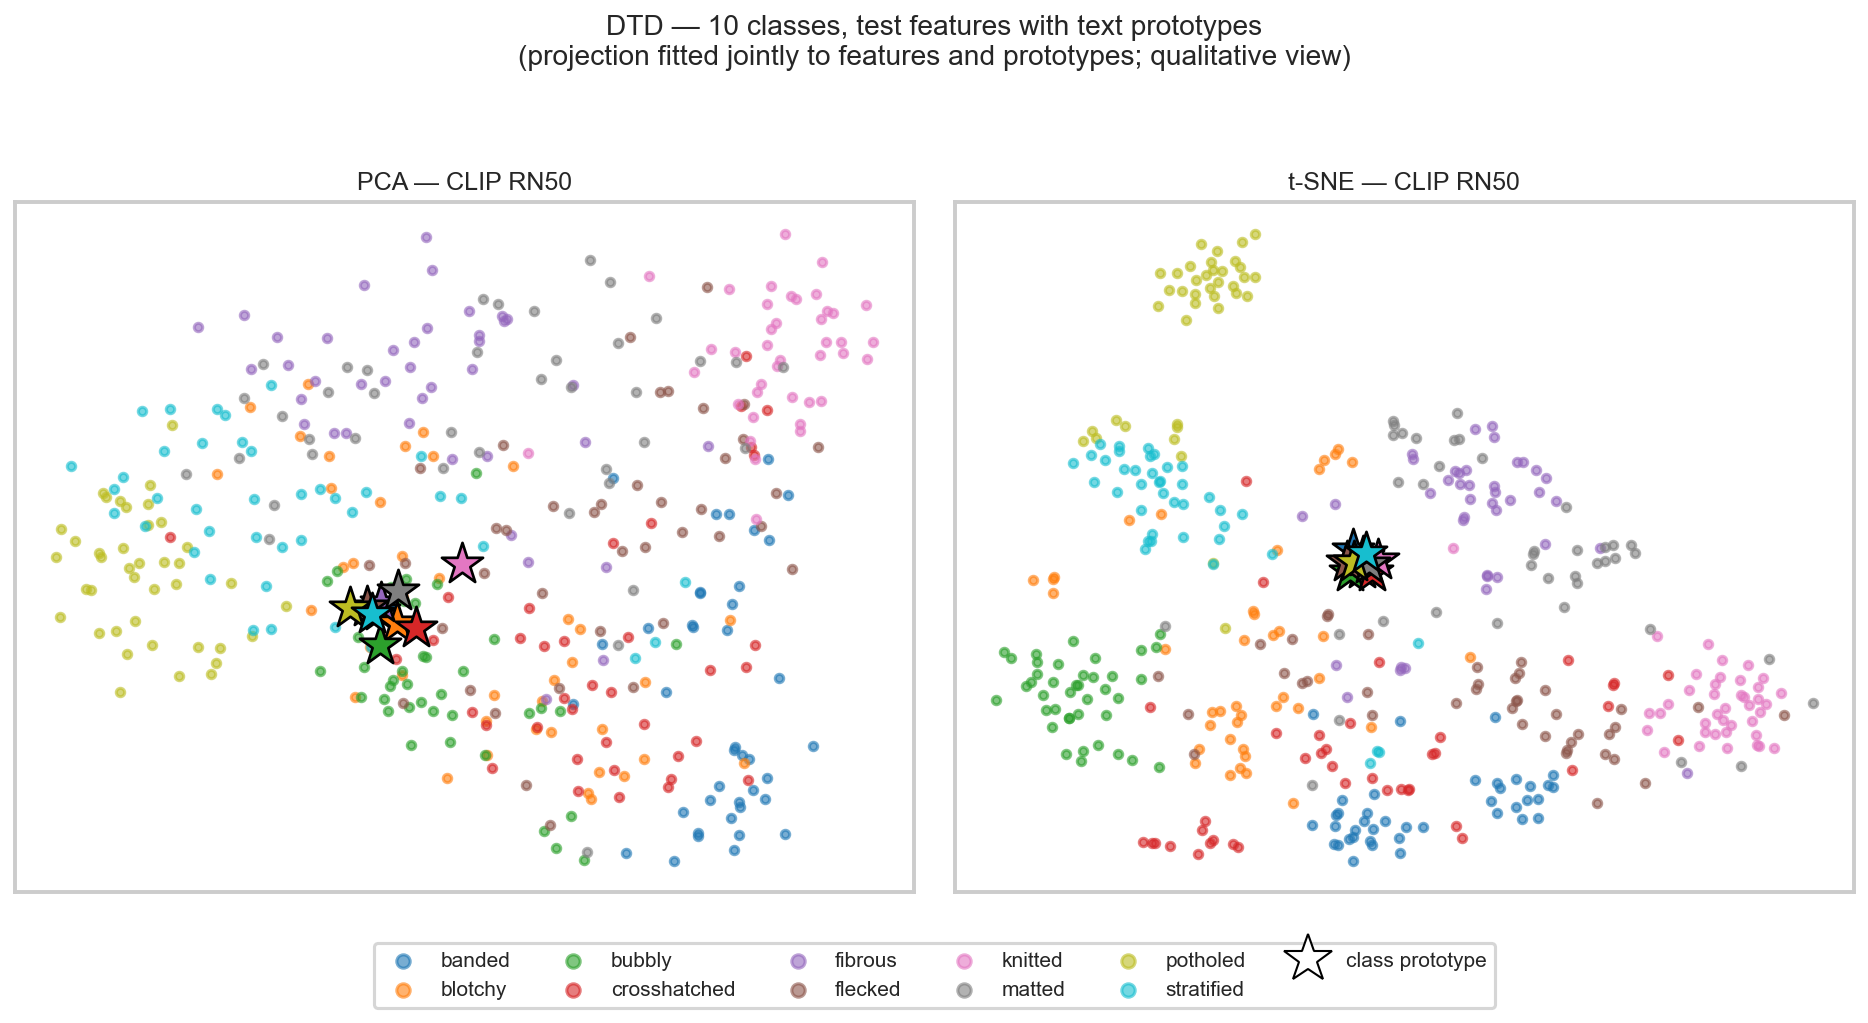

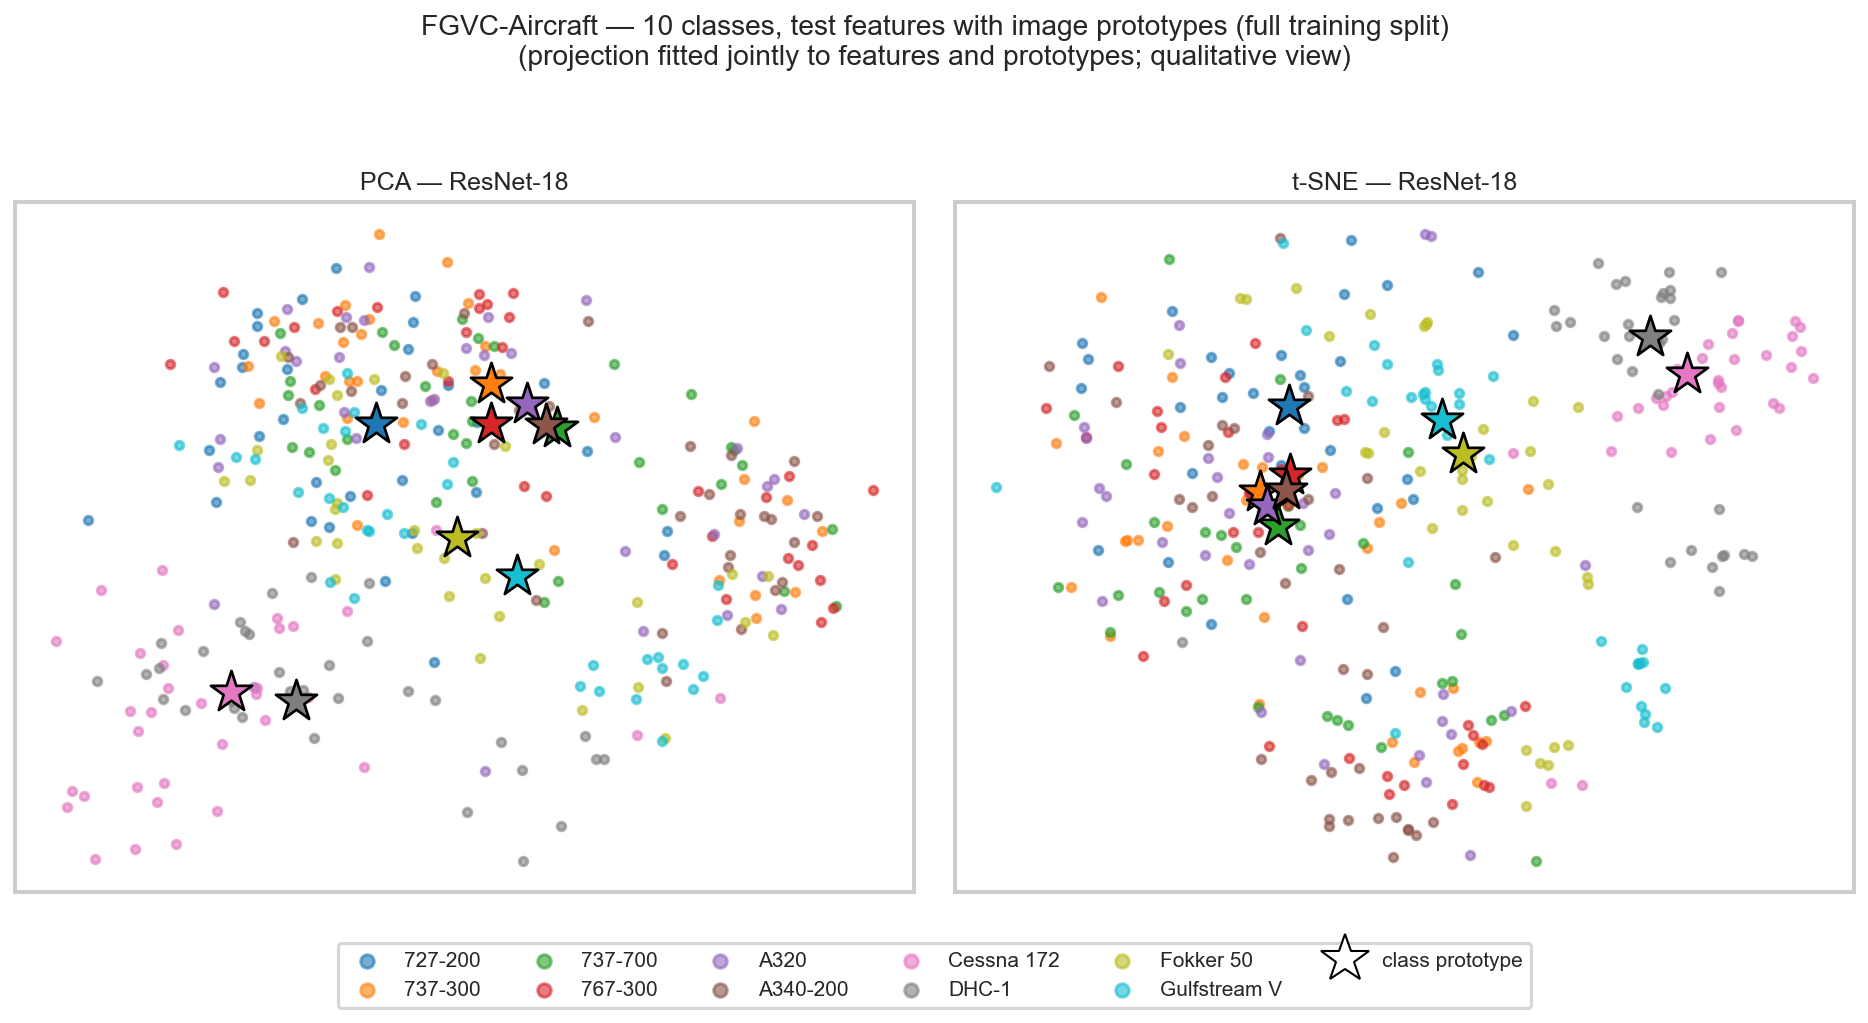

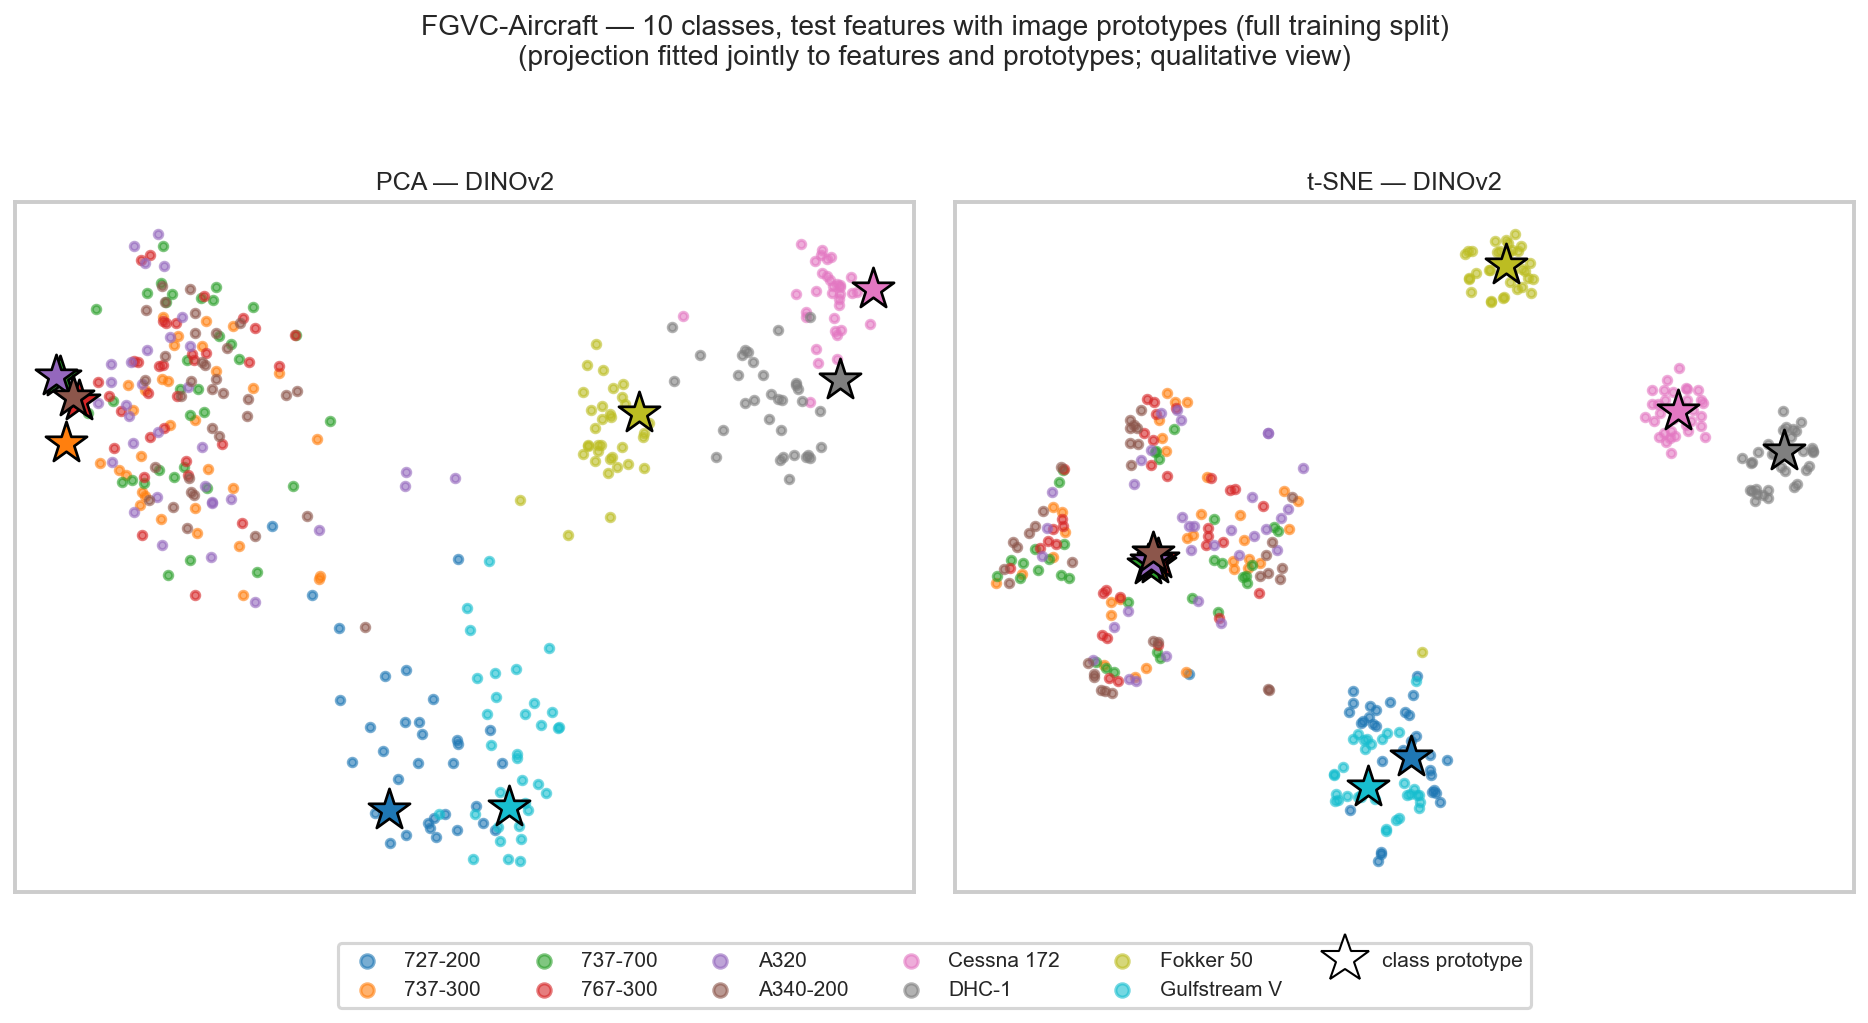

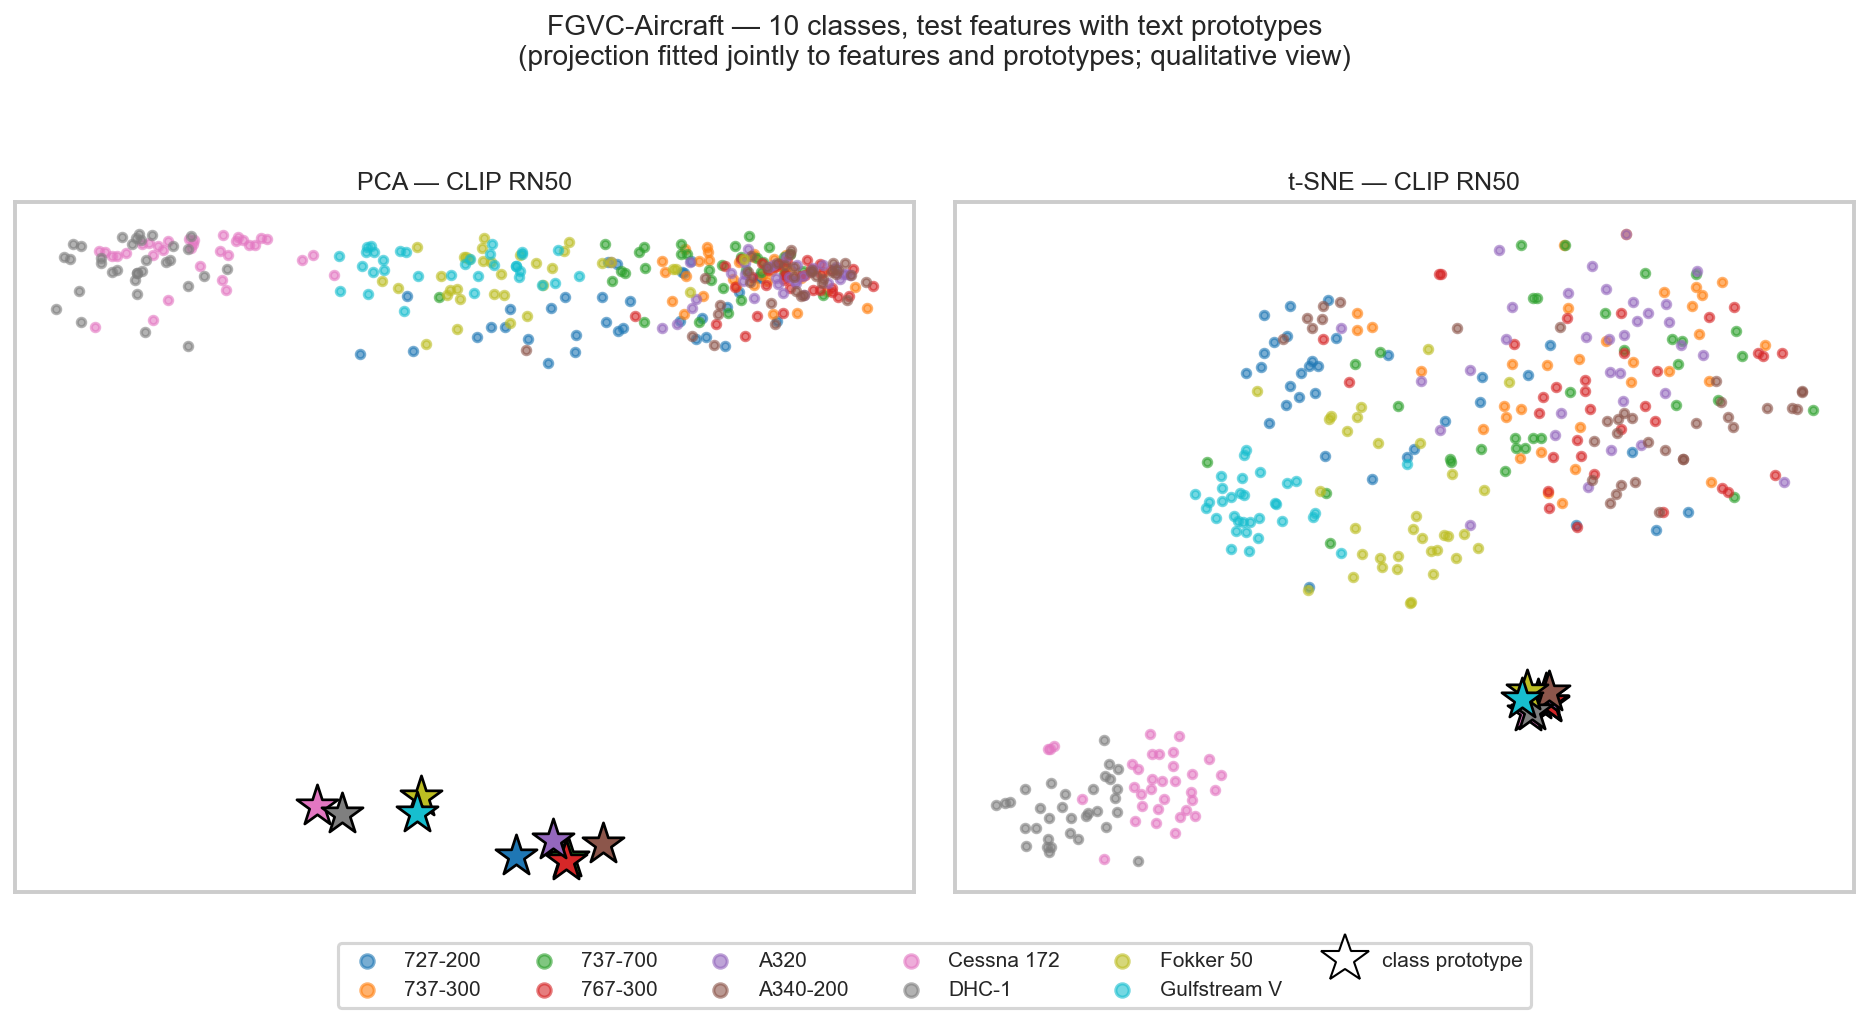

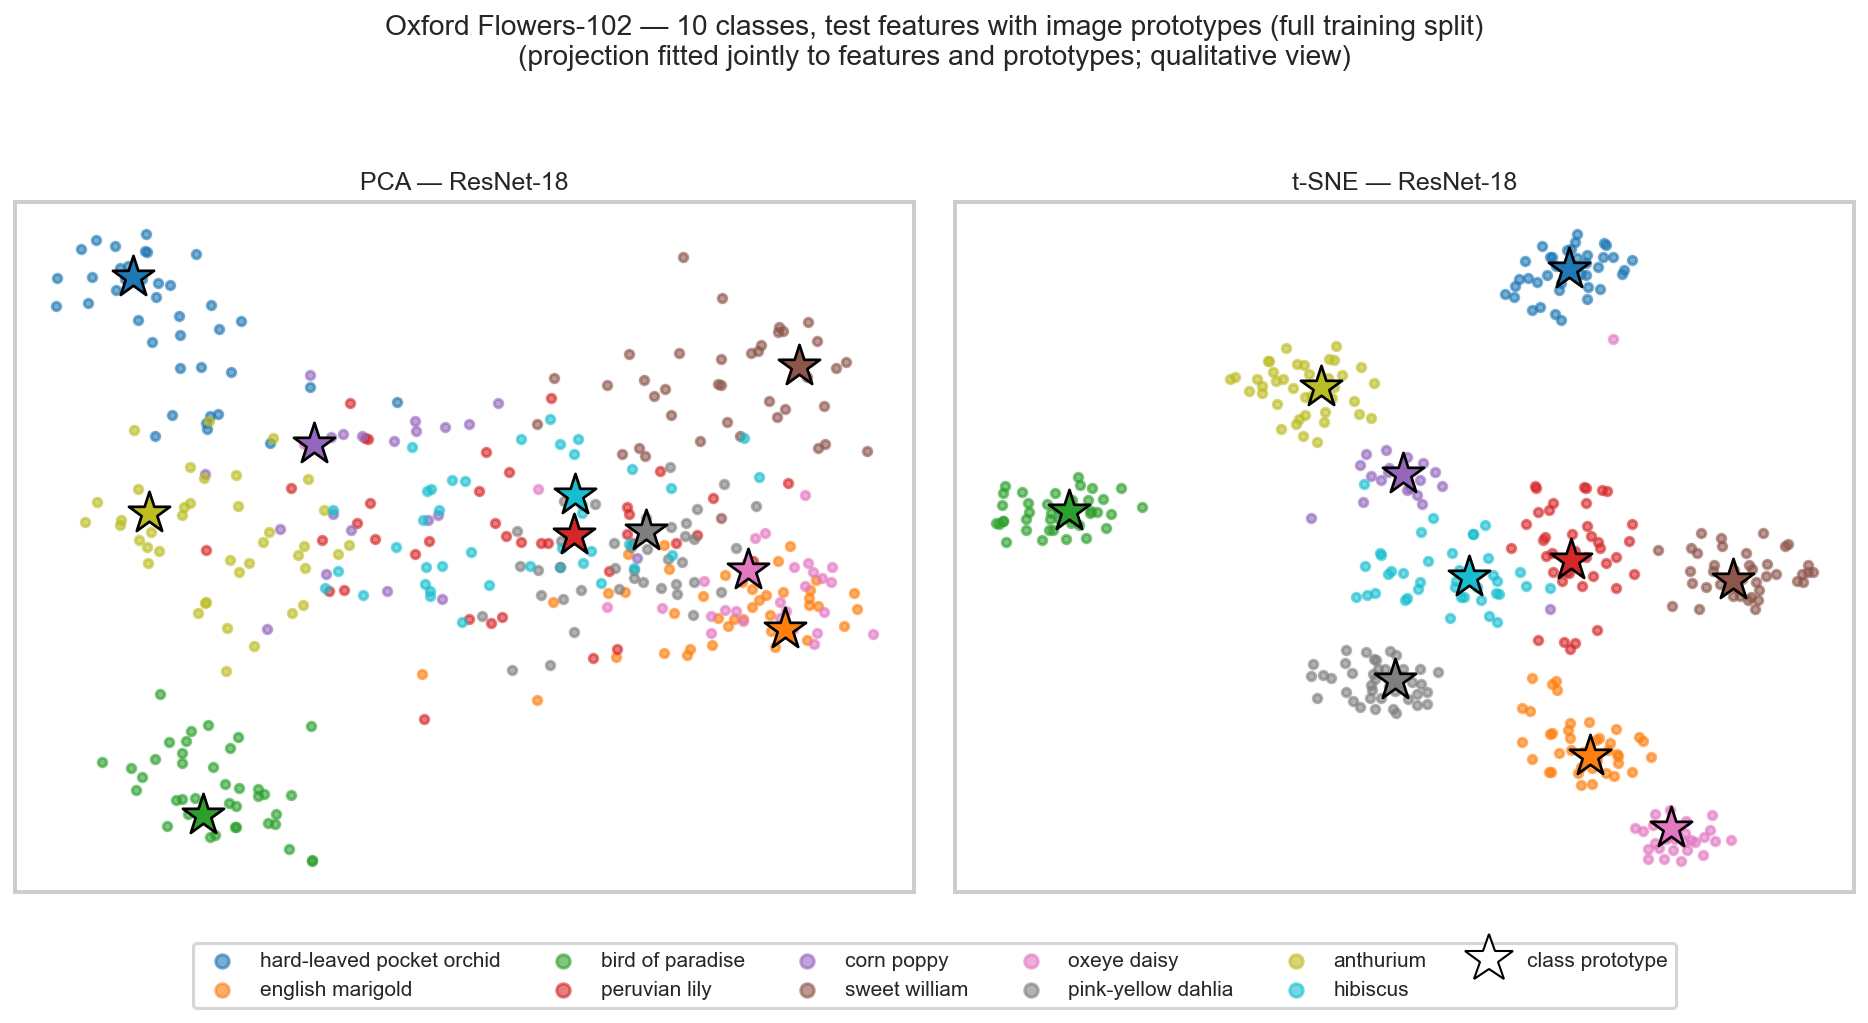

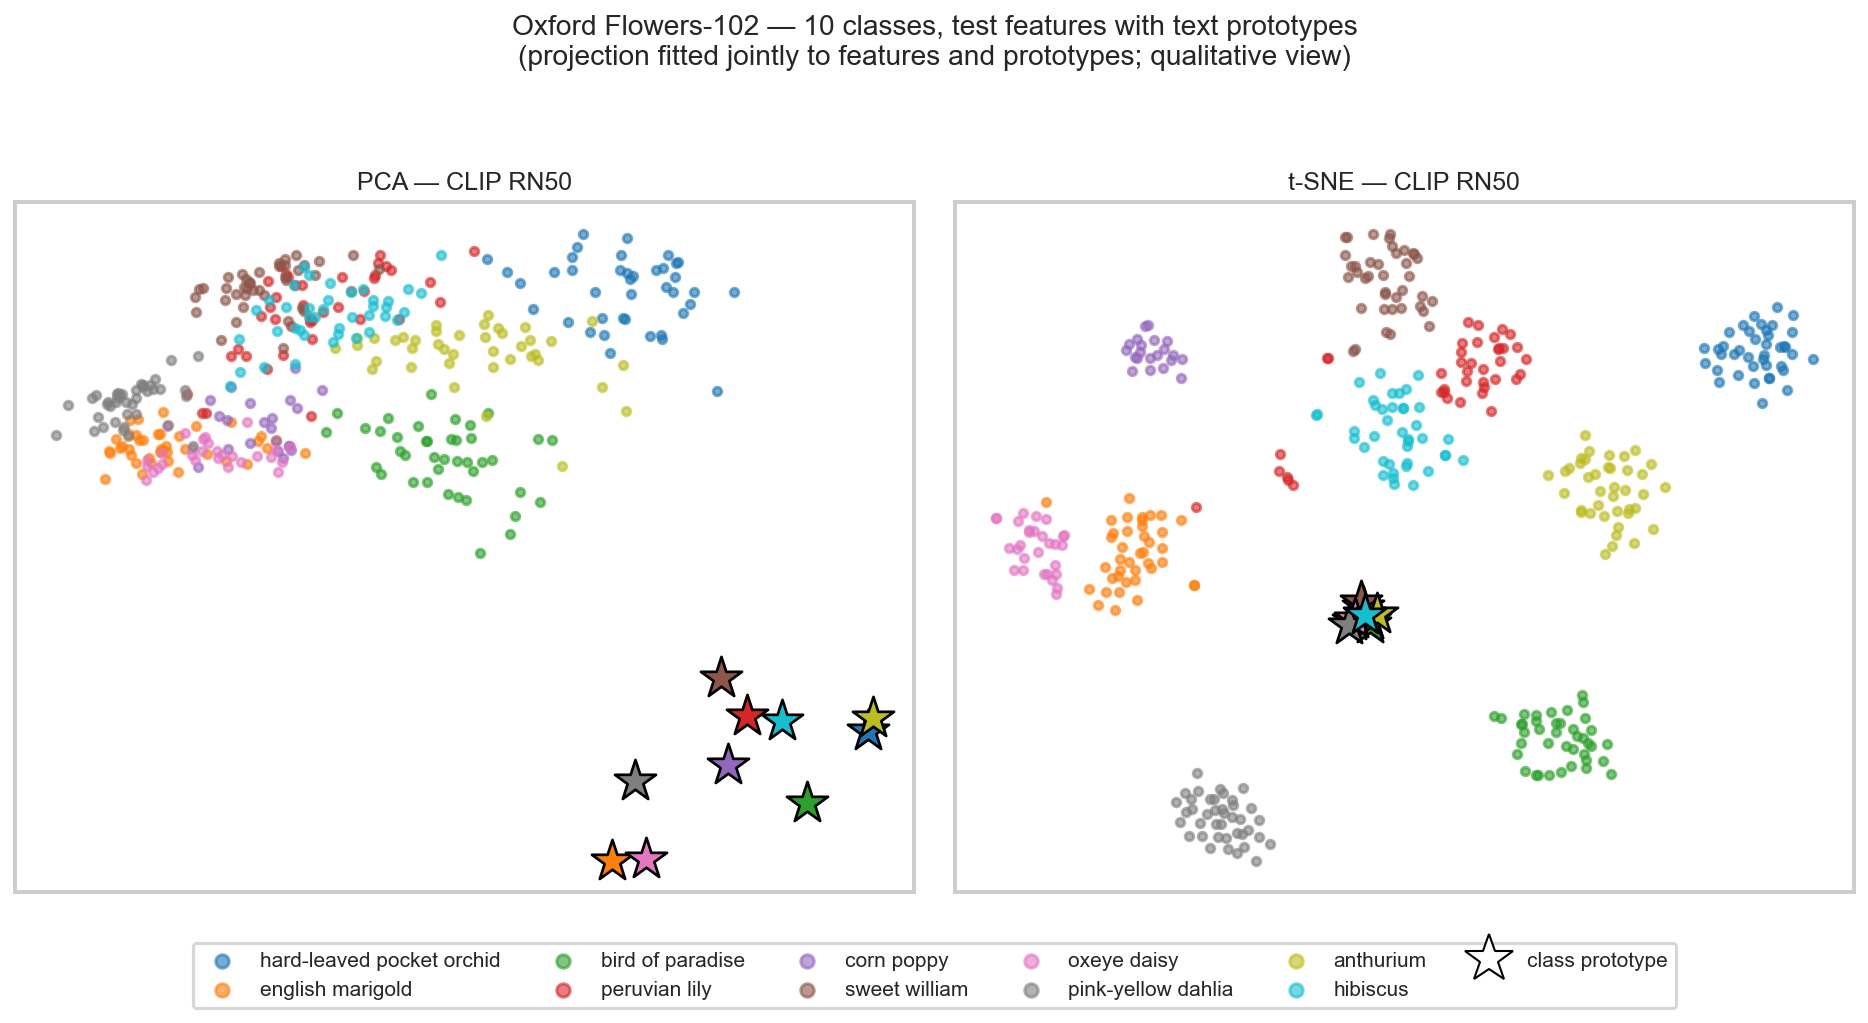

In [9]:
for name in ("features_dtd_resnet18.png", "features_dtd_clip_rn50.png",
             "features_fgvc_aircraft_resnet18.png", "features_fgvc_aircraft_dinov2_vits14.png",
             "features_fgvc_aircraft_clip_rn50.png",
             "features_flowers102_resnet18.png", "features_flowers102_clip_rn50.png"):
    p = REPO / "results" / "figures" / name
    if p.exists():
        display(Image(str(p), width=980))

## 6 · Discussion and handoff to Stage 2

The observations below are read directly off the tables and figures above; the numbers are loaded from `results/metrics/`, never typed by hand.

In [10]:
s = pd.read_csv(REPO / "results" / "metrics" / "summary.csv")
s["accuracy"] = (100 * s["mean_acc"]).round(2).astype(str)
s.loc[s["n_runs"] > 1, "accuracy"] += " ± " + (100 * s.loc[s["n_runs"] > 1, "std_acc"]).round(2).astype(str)

print("Best configuration per dataset (all baselines, any training-set size):")
best = s.loc[s.groupby("dataset")["mean_acc"].idxmax()]
display(best[["dataset", "encoder", "head", "k_shot", "accuracy"]])

print("\nGain from 5-shot to the full training split, per dataset/encoder/head:")
piv = s.pivot_table(index=["dataset", "encoder", "head"], columns="k_shot",
                    values="mean_acc")
if {"5shot", "full"}.issubset(piv.columns):
    piv["gain_5shot_to_full"] = (100 * (piv["full"] - piv["5shot"])).round(2)
    display(piv.dropna(subset=["gain_5shot_to_full"])[["5shot", "10shot", "full",
                                                       "gain_5shot_to_full"]].round(4))

Best configuration per dataset (all baselines, any training-set size):


,dataset,encoder,head,k_shot,accuracy
4,dtd,resnet18,linear_probe,full,62.84 ± 0.45
17,fgvc_aircraft,dinov2_vits14,linear_probe,full,67.21 ± 0.11
24,flowers102,resnet18,linear_probe,full,83.28 ± 0.11



Gain from 5-shot to the full training split, per dataset/encoder/head:


k_shot                                       5shot  10shot  full  \
dataset       encoder       head                                   
dtd           resnet18      image_prototype   0.47    0.53  0.59   
                            linear_probe      0.46    0.54  0.63   
fgvc_aircraft dinov2_vits14 image_prototype   0.23    0.28  0.34   
                            linear_probe      0.36    0.51  0.67   
              resnet18      image_prototype   0.16    0.20  0.25   
                            linear_probe      0.20    0.27  0.37   
flowers102    resnet18      image_prototype   0.70    0.75  0.75   
                            linear_probe      0.76    0.83  0.83   

k_shot                                       gain_5shot_to_full  
dataset       encoder       head                                 
dtd           resnet18      image_prototype               12.27  
                            linear_probe                  17.23  
fgvc_aircraft dinov2_vits14 image_prototype               11.30  
                            linear_probe                  30.73  
              resnet18      image_prototype                9.16  
                            linear_probe                  16.72  
flowers102    resnet18      image_prototype                5.03  
                            linear_probe                   7.70

### Choosing the branch that continues into Stage 2

Stage 2 replaces the decision layer with a Flow Matching model that transports an embedding toward a class representation, so the branch chosen here determines what the FM model is trained to reach: **image-derived class prototypes** (which change with the training-set size and with the encoder) or **fixed CLIP text prototypes** (identical for every K, and available with no labeled images at all).

The evidence to weigh, from the results above: which branch is stronger on the spec-selected datasets, how each behaves as the training set grows, and how much headroom each leaves for Stage 2 to demonstrate a gain. A branch that already sits near the ceiling gives Flow Matching nothing to improve.

### Artifacts handed to Stage 2/3

| Artifact | Path |
|---|---|
| Cached frozen features (train/val/test) | `results/features/{dataset}_{split}_{encoder}.pt` |
| Balanced K-shot training-subset indices | `results/artifacts/subsets/{dataset}_k{K}_seed{s}.pt` |
| CLIP RN50 text prototypes | `results/artifacts/clip_text_{dataset}.pt` |
| Per-run and summary results | `results/metrics/runs.csv`, `summary.csv`, `raw/*.npy` |
| Linear-probe training histories | `results/artifacts/curves/*.json` |

Stage 2 keeps the encoder frozen and reuses these caches and subset files, so its comparison against these baselines is made on identical data. Stage 3 places the Flow Matching module between the frozen encoder and the linear probe, trained jointly with cross-entropy — the linear-probe configuration reported here is that comparison's baseline.